In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
sfreq = 32
paradigm = P300(resample=sfreq, tmin=0, tmax=0.7, fmin=0.5, fmax=16)
#dataset = BNCI2014008()
dataset = EPFLP300()


In [3]:
subject, session, run = 1, "session_1", "run_1"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Not setting metadata
138 matching events found
No baseline correction applied


Number of events,138
Events,NonTarget: 115Target: 23
Time range,0.000 – 0.656 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


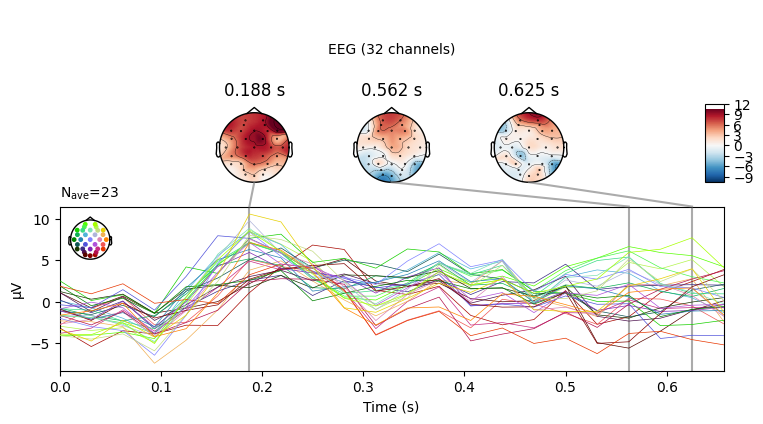

No projector specified for this dataset. Please consider the method self.add_proj.


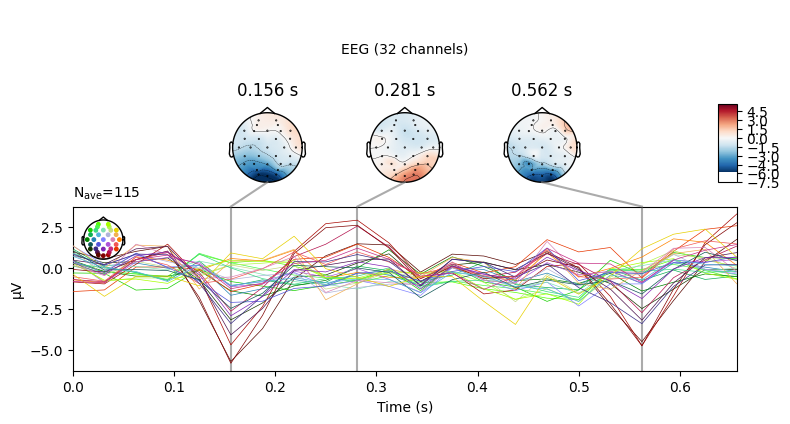

No projector specified for this dataset. Please consider the method self.add_proj.


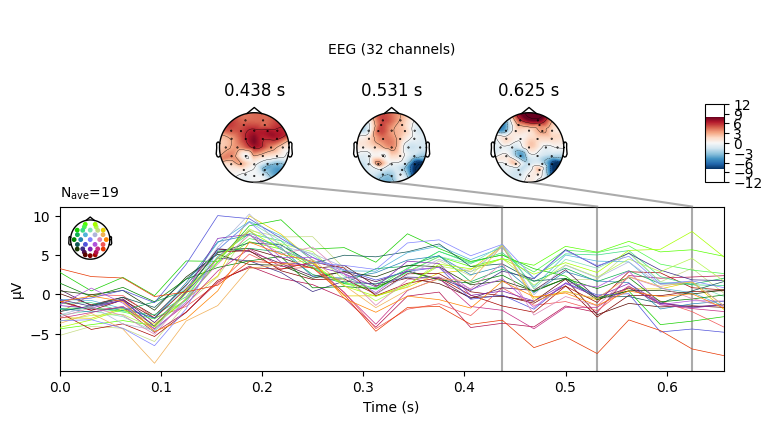

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
_ = target.plot_joint()
non_target = epochs['NonTarget'].average()
_ = non_target.plot_joint()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint()

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
roi0 = int((0 - epochs.tmin)*epochs.info['sfreq'])
roi1 = int((0.2 - epochs.tmin)*epochs.info['sfreq'])
n_times = roi1-roi0
n_epochs = len(epochs)
n_channels = len(epochs.ch_names)
n_lags= int(0.5*sfreq)
X = np.zeros((n_epochs, n_channels, n_times, n_lags))

for l in range(n_lags):
    X[:,:,:,l] = epochs.get_data()[:,:,roi0+l:roi1+l]
print(X.shape)

(138, 32, 6, 16)


In [7]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
import tensorly as tl

tl.set_backend('cupy')

split = len(epochs)//2
X_train = tl.tensor(X[:split])
X_test = tl.tensor(X[split:])
labels_train = labels[:split]
labels_test = labels[split:]
y_train = labels_train
y_test = labels_test

X_train /= np.std(X_train, axis=0)[np.newaxis,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:]
"""
print(X_train.shape)
X_train_mlsvd, _ = tensorly.decomposition.partial_tucker(X_train, modes=(1,), rank=X_train.shape[1])
plt.semilogy(np.mean(np.abs(X_train_mlsvd), axis=(0,2,3)), label='space')

X_train, factors = tensorly.decomposition.partial_tucker(X_train, modes=(1,), rank=8)
factors = [factors[0],tl.eye(X_train.shape[2]),tl.eye(X_train.shape[3])]
print(X_train.shape)
X_test = tensorly.tenalg.multi_mode_dot(X_test, factors, modes=(1,), transpose=True)
plt.semilogy(np.mean(np.abs(X_train), axis=(0,2,3)), label='space')


#plt.semilogy(np.mean(np.abs(X_train), axis=(0,1,3)), label='time')
#plt.semilogy(np.mean(np.abs(X_train), axis=(0,1,2)), label='lag')

#plt.legend()
"""
factors = [tl.eye(X_train.shape[1]),tl.eye(X_train.shape[2]),tl.eye(X_train.shape[3])]


In [8]:
#fig, axs = plt.subplots(1, X_train.shape[1], figsize=(16,6))
#for i in range(X_train.shape[1]):
#    w = factors[0][:,i]
#    plot_topomap(w, epochs.info, axes=axs[i], show=False)


In [ ]:
hoda = HODA(max_iter=128, rank=5, tol=1e-6,
            initialize ='svd', verbose=True,
            shrinkage='oas', toeplitz=None)
%lprun -f hoda.fit hoda.fit(X_train,y_train)
#hoda.fit(X_train,y_train)

[0/128]  shrinkage=0.0786  shrinkage=0.0585  shrinkage=0.1635  step=3.0248e+00
[1/128]  shrinkage=0.0834  shrinkage=0.1033  shrinkage=0.2367  step=2.8741e+00
[2/128]  shrinkage=0.0800  shrinkage=0.0627  shrinkage=0.1763  step=2.4590e+00
[3/128]  shrinkage=0.0812  shrinkage=0.0720  shrinkage=0.2559  step=1.9152e+00
[4/128]  shrinkage=0.0800  shrinkage=0.0708  shrinkage=0.2237  step=1.4085e+00
[5/128]  shrinkage=0.0811  shrinkage=0.0715  shrinkage=0.2535  step=1.0540e+00
[6/128]  shrinkage=0.0803  shrinkage=0.0728  shrinkage=0.2502  step=1.0029e+00
[7/128]  shrinkage=0.0814  shrinkage=0.0714  shrinkage=0.2469  step=9.7754e-01
[8/128]  shrinkage=0.0803  shrinkage=0.0741  shrinkage=0.2676  step=9.3261e-01
[9/128]  shrinkage=0.0815  shrinkage=0.0716  shrinkage=0.2434  step=9.0785e-01
[10/128]  shrinkage=0.0803  shrinkage=0.0747  shrinkage=0.2772  step=8.5928e-01
[11/128]  shrinkage=0.0816  shrinkage=0.0718  shrinkage=0.2415  step=8.3013e-01
[12/128]  shrinkage=0.0803  shrinkage=0.0751  shri

In [ ]:
import cupy

plt.semilogy(cupy.asnumpy(hoda.updates_[:,:hoda.iter_]))
plt.show()

In [ ]:

fig, axs = plt.subplots(3,hoda.rank, figsize=(16,6*3))
projs = [cupy.asnumpy(factors[k] @ p) for k,p in enumerate(hoda.projs_)]
for i in range(hoda.rank):
    w = projs[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(projs[1]))
for i in range(hoda.rank):
    w = projs[1][:,i]
    axs[1,i].plot(epochs.times[roi0:roi1], w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])
for i in range(hoda.rank):
    w = cupy.asnumpy(projs[2][:,i])
    axs[2,i].plot(np.arange(n_lags)/epochs.info['sfreq'], w)
    axs[2,i].set_xlabel('Time (s)')
    axs[2,i].set_ylabel('Weight')
    axs[2,i].set_ylim([-vmax, vmax])


In [ ]:
for k in range(3):
    cov = cupy.asnumpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

In [ ]:
for k in range(3):
    cov = cupy.asnumpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

In [ ]:
fig, axs = plt.subplots(3,hoda.rank, figsize=(16,6*3))
aps = [cupy.asnumpy(factors[k] @ hoda.scatter_w_[k] @ p) for k,p in enumerate(hoda.projs_)]
for i in range(hoda.rank):
    w = aps[0][:,i]
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)
vmax = np.max(np.abs(aps[1]))
for i in range(hoda.rank):
    w = aps[1][:,i]
    axs[1,i].plot(epochs.times[roi0:roi1], w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].set_ylim([-vmax, vmax])
    axs[1,i].sharex(axs[2,0])
    axs[1,i].sharey(axs[2,0])

for i in range(hoda.rank):
    w = aps[2][:,i]
    axs[2,i].plot(np.arange(n_lags)/epochs.info['sfreq'], w)
    axs[2,i].set_xlabel('Time (s)')
    axs[2,i].set_ylabel('Weight')
    axs[2,i].set_ylim([-vmax, vmax])
    axs[2,i].sharex(axs[2,0])
    axs[2,i].sharey(axs[2,0])

In [ ]:
Xt_train = cupy.asnumpy(hoda.transform(X_train))
Xt_test = cupy.asnumpy(hoda.transform(X_test))
print(Xt_train.shape)
print(Xt_test.shape)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

#classifier = LogisticRegression(penalty='l1', solver='liblinear')
classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)
classifier.fit(Xt_train,y_train)
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()

In [ ]:
import seaborn as sns
import pandas as pd

n_features = Xt_train.shape[-1]
df_train = pd.DataFrame(Xt_train[:,feature_order[:4]])
df_train['label'] = y_train
g = sns.pairplot(df_train, hue='label')

In [ ]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

In [ ]:
df_test = pd.DataFrame(Xt_test[:,feature_order[:4]])
df_test['label'] = y_test
g = sns.pairplot(df_test, hue='label')

In [ ]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])